In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
df=pd.read_csv("netflix_user_behavior_churn_50000v2.csv")
df.head()

,user_id,age,gender,region,subscription_type,payment_method,primary_device,account_age_months,favorite_genre,time_of_day,recommendation_source,session_count,avg_watch_time_minutes_per_week,watch_sessions_per_week,completion_rate,avg_rating_given,app_rating,recommendation_click_rate,days_since_last_login,churned
0,N00001,33,Male,Europe,Basic,Credit Card,Smart TV,38,Comedy,Afternoon,Trending,1,259,4,79,4,4,48,3,0
1,N00002,41,Male,Africa,Premium,Credit Card,Tablet,49,Comedy,Evening,Search,1,164,4,69,4,4,32,30,0
2,N00003,28,Female,Europe,Standard,Gift Card,Laptop,20,Drama,Evening,Ads,1,304,5,75,4,3,31,5,1
3,N00004,40,Female,North America,Basic,Credit Card,Mobile,19,Action,Evening,Algorithm,1,145,6,79,4,4,39,38,0
4,N00005,54,Male,Europe,Standard,Paypal,Mobile,51,Romance,Evening,Friend,3,108,1,58,5,4,50,5,0


In [4]:
df.describe()

,age,account_age_months,session_count,avg_watch_time_minutes_per_week,watch_sessions_per_week,completion_rate,avg_rating_given,app_rating,recommendation_click_rate,days_since_last_login,churned
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,39.215900,44.803340,1.630120,277.950640,5.731460,73.127260,3.844560,3.946220,38.640680,12.301380,0.209280
std,13.071976,21.890139,0.988579,157.604512,3.467176,11.148734,0.611887,0.639168,19.474178,15.453764,0.406799
min,19.000000,1.000000,1.000000,15.000000,1.000000,23.000000,2.000000,2.000000,0.000000,0.000000,0.000000
25%,31.000000,29.000000,1.000000,165.000000,3.000000,66.000000,3.000000,4.000000,24.000000,1.000000,0.000000
50%,37.000000,45.000000,1.000000,240.000000,5.000000,74.000000,4.000000,4.000000,37.000000,4.000000,0.000000
75%,45.000000,60.000000,2.000000,349.000000,7.000000,81.000000,4.000000,4.000000,52.000000,22.000000,0.000000
max,79.000000,135.000000,5.000000,820.000000,19.000000,100.000000,5.000000,5.000000,100.000000,60.000000,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   user_id                          50000 non-null  str  
 1   age                              50000 non-null  int64
 2   gender                           50000 non-null  str  
 3   region                           50000 non-null  str  
 4   subscription_type                50000 non-null  str  
 5   payment_method                   50000 non-null  str  
 6   primary_device                   50000 non-null  str  
 7   account_age_months               50000 non-null  int64
 8   favorite_genre                   50000 non-null  str  
 9   time_of_day                      50000 non-null  str  
 10  recommendation_source            50000 non-null  str  
 11  session_count                    50000 non-null  int64
 12  avg_watch_time_minutes_per_week  50000 non-null  int64
 1

In [6]:
df.isnull().sum()

user_id                            0
age                                0
gender                             0
region                             0
subscription_type                  0
payment_method                     0
primary_device                     0
account_age_months                 0
favorite_genre                     0
time_of_day                        0
recommendation_source              0
session_count                      0
avg_watch_time_minutes_per_week    0
watch_sessions_per_week            0
completion_rate                    0
avg_rating_given                   0
app_rating                         0
recommendation_click_rate          0
days_since_last_login              0
churned                            0
dtype: int64

In [7]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Length: 50000, dtype: bool

In [8]:
df.drop("user_id", axis=1, inplace=True)

In [9]:
df.head()


,age,gender,region,subscription_type,payment_method,primary_device,account_age_months,favorite_genre,time_of_day,recommendation_source,session_count,avg_watch_time_minutes_per_week,watch_sessions_per_week,completion_rate,avg_rating_given,app_rating,recommendation_click_rate,days_since_last_login,churned
0,33,Male,Europe,Basic,Credit Card,Smart TV,38,Comedy,Afternoon,Trending,1,259,4,79,4,4,48,3,0
1,41,Male,Africa,Premium,Credit Card,Tablet,49,Comedy,Evening,Search,1,164,4,69,4,4,32,30,0
2,28,Female,Europe,Standard,Gift Card,Laptop,20,Drama,Evening,Ads,1,304,5,75,4,3,31,5,1
3,40,Female,North America,Basic,Credit Card,Mobile,19,Action,Evening,Algorithm,1,145,6,79,4,4,39,38,0
4,54,Male,Europe,Standard,Paypal,Mobile,51,Romance,Evening,Friend,3,108,1,58,5,4,50,5,0


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'account_age_months'}>,
        <Axes: title={'center': 'session_count'}>],
       [<Axes: title={'center': 'avg_watch_time_minutes_per_week'}>,
        <Axes: title={'center': 'watch_sessions_per_week'}>,
        <Axes: title={'center': 'completion_rate'}>],
       [<Axes: title={'center': 'avg_rating_given'}>,
        <Axes: title={'center': 'app_rating'}>,
        <Axes: title={'center': 'recommendation_click_rate'}>],
       [<Axes: title={'center': 'days_since_last_login'}>,
        <Axes: title={'center': 'churned'}>, <Axes: >]], dtype=object)

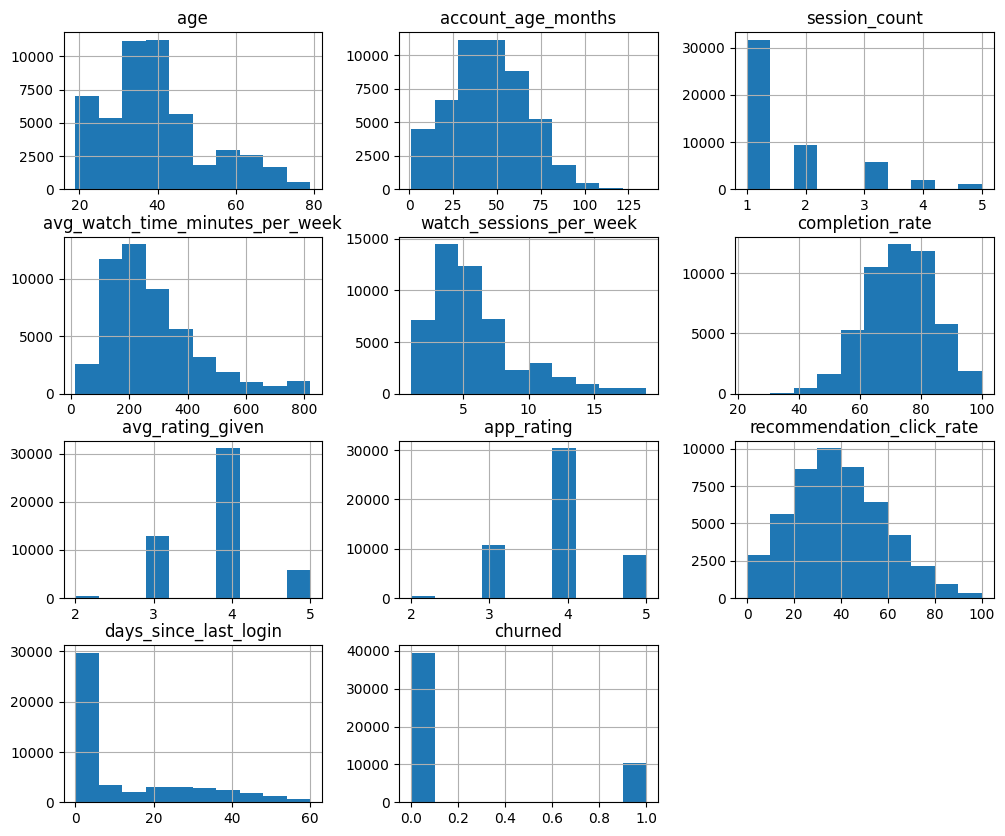

In [10]:
df.hist(figsize=(12, 10))

In [11]:
x=df.drop("churned",axis=1)
y = df["churned"]

In [12]:
num_cols=x.select_dtypes(include=["float64",'int64']).columns
cat_cols=x.select_dtypes(include=["object"]).columns

C:\Users\pc\AppData\Local\Temp\ipykernel_11344\915837234.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=x.select_dtypes(include=["object"]).columns


In [13]:
cat_cols

Index(['gender', 'region', 'subscription_type', 'payment_method',
       'primary_device', 'favorite_genre', 'time_of_day',
       'recommendation_source'],
      dtype='str')

In [14]:
num_cols

Index(['age', 'account_age_months', 'session_count',
       'avg_watch_time_minutes_per_week', 'watch_sessions_per_week',
       'completion_rate', 'avg_rating_given', 'app_rating',
       'recommendation_click_rate', 'days_since_last_login'],
      dtype='str')

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

<Axes: xlabel='churned'>

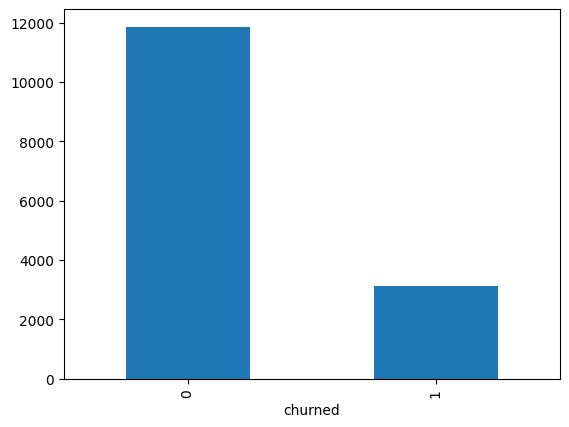

In [16]:
# y_test.hist(bins=50, figsize=(20,15))
y_test.value_counts().plot(kind="bar")

<Axes: xlabel='churned'>

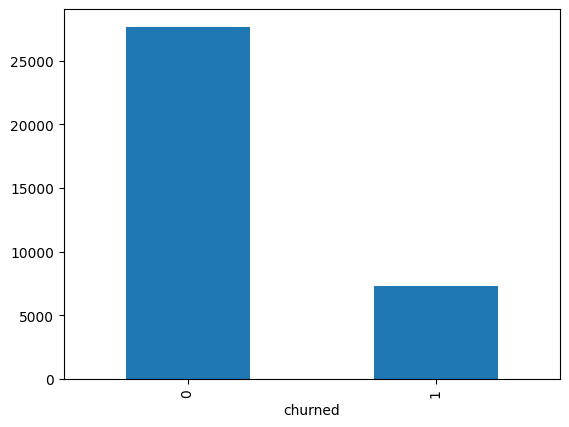

In [17]:
y_train.value_counts().plot(kind="bar")

In [18]:
one_hot_cols = [
    "gender",
    "region",
    "payment_method",
    "primary_device",
    "favorite_genre",
    "time_of_day",
    "recommendation_source"
]

ordinal_cols = ["subscription_type"]

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), one_hot_cols),
        ("ordinal", OrdinalEncoder(), ordinal_cols),
        ("num", StandardScaler(), num_cols)
    ],
    remainder="passthrough"
)

In [20]:
transformed_x_train = preprocessor.fit_transform(x_train)
pd.DataFrame(transformed_x_train, columns=preprocessor.get_feature_names_out())

,onehot__gender_Female,onehot__gender_Male,onehot__region_Africa,onehot__region_Asia,onehot__region_Europe,onehot__region_North America,onehot__region_Oceania,onehot__region_South America,onehot__payment_method_Credit Card,onehot__payment_method_Debit Card,...,num__age,num__account_age_months,num__session_count,num__avg_watch_time_minutes_per_week,num__watch_sessions_per_week,num__completion_rate,num__avg_rating_given,num__app_rating,num__recommendation_click_rate,num__days_since_last_login
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.782719,-1.364606,2.388221,0.817502,0.363672,1.417536,1.892429,-1.486877,-0.443242,-0.604467
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2.743526,1.241004,0.369949,0.259739,-0.213415,-1.002066,0.257158,0.079953,-0.288999,-0.733633
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.976951,0.143905,-0.639187,0.151989,0.075128,0.252543,0.257158,0.079953,-0.751728,-0.087805
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.750431,0.326755,0.369949,0.145651,-0.213415,-0.464377,-1.378113,0.079953,-0.648899,-0.669050
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.053609,-0.816056,-0.639187,-0.488170,-1.079044,-0.912451,-1.378113,-1.486877,-0.648899,-0.669050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.137171,-0.130369,-0.639187,-0.862125,-0.501958,-1.539756,0.257158,-1.486877,-0.237585,1.655931
34996,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,-0.169459,-1.136043,2.388221,3.435184,2.094931,1.148692,1.892429,1.646784,0.687871,-0.475302
34997,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-1.395979,-0.450356,-0.639187,-1.014242,-0.790501,-1.450141,-1.378113,-1.486877,-0.957385,1.462182
34998,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.395979,-1.273181,3.397356,1.641469,0.940758,0.790232,1.892429,0.079953,0.482214,-0.669050


In [21]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((35000, 18), (15000, 18), (35000,), (15000,))

In [22]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.pipeline import Pipeline

In [23]:
pipelines = {}

models = {
    "mlp": MLPClassifier(),
    "rf": RandomForestClassifier(class_weight="balanced"),
    "gb": GradientBoostingClassifier(),
}

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(x_train, y_train)

    score = pipeline.score(x_test, y_test)

    pipelines[name] = pipeline

    print(f"{name} score is {score}")

c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


mlp score is 0.8594
rf score is 0.8674666666666667
gb score is 0.8743333333333333


In [24]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_val_score(pipeline, x, y, cv=5, scoring="f1_macro")
    
    print(f"{name} CV score: {scores.mean():.4f}")

c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization has

mlp CV score: 0.7723
rf CV score: 0.7663
gb CV score: 0.7897


In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200,300],
    "model__learning_rate": [ 0.1, 0.2,0.3],
    
    
}

grid = GridSearchCV(
    pipelines["gb"],
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
    
)
grid.fit(x_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)


Best params: {'model__learning_rate': 0.2, 'model__n_estimators': 100}
Best score: 0.7920221983058409


In [26]:
best_model = grid.best_estimator_

In [27]:
import joblib
from sklearn.metrics import accuracy_score,recall_score,f1_score,confusion_matrix
y_pred=best_model.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.8766


In [28]:
joblib.dump(best_model, "netflix_model.pkl")

['netflix_model.pkl']

In [29]:
def Alg_acc(y_test,y_pred):
    acc=accuracy_score(y_test,y_pred)
    rs=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    return "acc",acc,"rs",rs,"f1",f1
print(confusion_matrix(y_test,y_pred))   


[[11268   593]
 [ 1258  1881]]


In [30]:
print(Alg_acc(y_test,y_pred))

('acc', 0.8766, 'rs', 0.5992354252946799, 'f1', 0.6702298236237306)
